<h3> Method with Attention-pooled mean the centeroid embedding of a document and and HDBSCAN for clustering. </h3>

<h5> Imports </h5>

In [1]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [2]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

Found 1068 JSON files in data_output/embeddings
Loaded: Fortimo_LED_Strip_5ft_MF_9xx_LV6_embeddings.json
Loaded: dig-sr-connector_embeddings.json
Loaded: Fortimo_LED_Strip_0.25ft_MF_9xx_HV6_x_2pcs_embeddings.json
Loaded: 202308-1-design-in-guide-led-indoor-driver-spot-downlight_embeddings.json
Loaded: SIG-Xitanium-SR-Bridge-DIG-A11_embeddings.json
Loaded: Datasheet_LED_Transformer_75W_24VDC_120-277V_IP67_929003413906_embeddings.json
Loaded: Fortimo-LED-Square-1250lm-9xx-HV-LV3_embeddings.json
Loaded: Fortimo_LED_Strip_CED_1ft_MF_FC_LV5__embeddings.json
Loaded: Fortimo-LED-Strip-PR-FT-2ft-2200lm-927-965-FC-HV5_embeddings.json
Loaded: Datasheet-Fortimo-1100-lm_embeddings.json
Loaded: Fortimo_LED_Line_1ft_MF_8xx_1R_LV5__embeddings.json
Loaded: LED_Transformer_120W_24VDC_913710032567_embeddings.json
Loaded: Fortimo_SLM_C_1201_L09_1313_G7N_HE_plus__embeddings.json
Loaded: Fortimo_LED_Strip_2ft_2200lm_9xx_LV4__embeddings.json
Loaded: Fortimo_FastFlex_2x6_DA_G4plus_embeddings.json
Loaded: Xit

<h5> Compute an Attention-pooled mean from individual chunks (page embeddings) for each document </h5>

In [3]:
import numpy as np

def doc_vector_attention_pool(page_embeddings, alpha=5.0, iters=3):
    """
    Attention-like pooling: pages closer to the center get higher weight.
    page_embeddings: List[np.ndarray] (L2-normalized)
    alpha: sharpness of attention (5–10 works well)
    iters: refinement steps
    """
    if not page_embeddings:
        return None
    
    V = np.vstack(page_embeddings).astype("float32")  # (n,d)
    if len(V) == 1:
        return V[0]

    # start with simple mean
    c = V.mean(axis=0)
    c /= (np.linalg.norm(c) + 1e-12)

    for _ in range(iters):
        sims = V @ c  # cosine, since everything is normalized
        w = np.exp(alpha * sims)
        w /= (w.sum() + 1e-12)
        c = (w[:, None] * V).sum(axis=0)
        c /= (np.linalg.norm(c) + 1e-12)

    return c

In [4]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = doc_vector_attention_pool(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

In [5]:
# Extract doc vectors from all_results
doc_vectors = []
doc_names = []

for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc_vectors.append(doc['doc_vector'])
        # Extract just the filename without path
        filename = os.path.basename(doc['file'])
        doc_names.append(filename)

# Convert to numpy array
doc_vectors_array = np.array(doc_vectors)

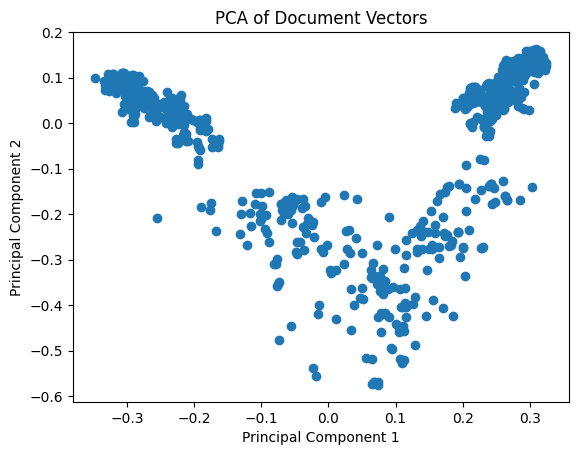

In [6]:
# Convert X to numpy array and apply dimensionality reduction for visualization
from sklearn.decomposition import PCA

X = [doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None]
X_array = np.array(X)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_array)
plt.scatter(X_2d[:, 0], X_2d[:, 1])
plt.title("PCA of Document Vectors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [7]:
import numpy as np
import hdbscan

# doc_vectors_array = (n_docs, d) normalized document embeddings

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,      # tune later
    min_samples=10,
    metric='euclidean'       # cosine also works but euclidean with normalized vectors = same
)

labels = clusterer.fit_predict(doc_vectors_array)

# Attach labels to documents
for doc, label in zip(all_results, labels):
    doc['cluster'] = int(label)

# Show cluster summary
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} documents")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

/Volumes/BackupHD/Projects/variant-logic/vl-blogs/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/BackupHD/Projects/variant-logic/vl-blogs/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Cluster -1: 229 documents
Cluster 0: 15 documents
Cluster 1: 17 documents
Cluster 2: 23 documents
Cluster 3: 17 documents
Cluster 4: 13 documents
Cluster 5: 18 documents
Cluster 6: 69 documents
Cluster 7: 40 documents
Cluster 8: 16 documents
Cluster 9: 13 documents
Cluster 10: 127 documents
Cluster 11: 212 documents
Cluster 12: 12 documents
Cluster 13: 33 documents
Cluster 14: 27 documents
Cluster 15: 136 documents
Cluster 16: 47 documents


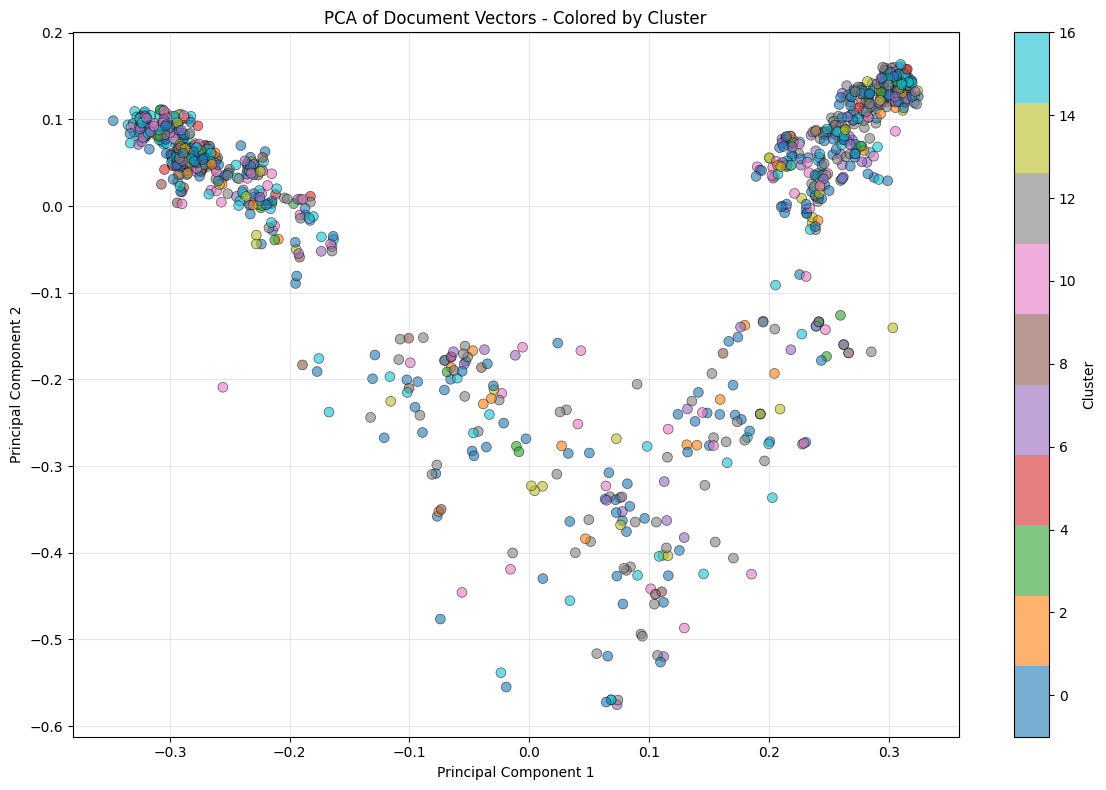


Cluster distribution in the visualization:
Cluster -1: 232 documents
Cluster 0: 15 documents
Cluster 1: 17 documents
Cluster 2: 23 documents
Cluster 3: 17 documents
Cluster 4: 13 documents
Cluster 5: 18 documents
Cluster 6: 69 documents
Cluster 7: 40 documents
Cluster 8: 16 documents
Cluster 9: 13 documents
Cluster 10: 127 documents
Cluster 11: 210 documents
Cluster 12: 12 documents
Cluster 13: 33 documents
Cluster 14: 27 documents
Cluster 15: 135 documents
Cluster 16: 47 documents


In [8]:
# Visualize clusters using PCA with different colors for each cluster
plt.figure(figsize=(12, 8))

# Get cluster labels for documents with vectors
cluster_labels_for_plot = []
for doc in all_results:
    if doc.get('doc_vector') is not None:
        cluster_labels_for_plot.append(doc.get('cluster', -1))

# Create scatter plot with different colors for each cluster
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels_for_plot, 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.title("PCA of Document Vectors - Colored by Cluster")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print cluster distribution
print("\nCluster distribution in the visualization:")
unique_clusters, counts = np.unique(cluster_labels_for_plot, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster_id}: {count} documents")

In [9]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-11")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")

Cluster 0: 15 files copied to data_output/clusters-11/cluster0
Cluster 1: 17 files copied to data_output/clusters-11/cluster1
Cluster 2: 23 files copied to data_output/clusters-11/cluster2
Cluster 3: 17 files copied to data_output/clusters-11/cluster3
Cluster 4: 13 files copied to data_output/clusters-11/cluster4
Cluster 5: 18 files copied to data_output/clusters-11/cluster5
Cluster 6: 69 files copied to data_output/clusters-11/cluster6
Cluster 7: 40 files copied to data_output/clusters-11/cluster7
Cluster 8: 16 files copied to data_output/clusters-11/cluster8
Cluster 9: 13 files copied to data_output/clusters-11/cluster9
Cluster 10: 127 files copied to data_output/clusters-11/cluster10
Cluster 11: 212 files copied to data_output/clusters-11/cluster11
Cluster 12: 12 files copied to data_output/clusters-11/cluster12
Cluster 13: 33 files copied to data_output/clusters-11/cluster13
Cluster 14: 27 files copied to data_output/clusters-11/cluster14
Cluster 15: 136 files copied to data_output